# Cardiac fibrosis pipeline: participant-free synthetic demonstration

This notebook walks through every stage of the pipeline (`01_imaging` through
`08_clinical_associations`) on fully synthetic data, using code that mirrors
the structure of the original scripts as closely as possible.

**What this is:** a demonstration that the code runs correctly end to end and
a walkthrough of what each stage's output represents, for code review.

**What this is not:** a reproduction of the manuscript's results. The
synthetic cohort is 320 subjects (vs. 50,239 in the real study), the
imaging models train for a handful of epochs on ~40 synthetic images (vs.
200 epochs on 42,083 real images), and the MR/colocalization stages
reimplement the same standard statistical formulas the original R packages
(`TwoSampleMR`, `MendelianRandomization`, `coloc`) use, in Python, to keep
this notebook to a single environment. None of the numbers below should be
cited as scientific results.

**Data:** every value in `demo/example_data/` is procedurally generated by
[`generate_synthetic_data.py`](generate_synthetic_data.py) with a fixed seed
(42) -- see that file and [`example_data/README.md`](example_data/README.md)
for exactly how. No UK Biobank data, participant identifier, real genetic
variant, or real protein name appears anywhere in this notebook.

**UK Biobank data access:** this repository's imaging, genotype, and
proteomic pipeline runs on UK Biobank data under approved application 22282.
UK Biobank data cannot be redistributed; researchers who want to run this
pipeline on real data need their own approved UK Biobank access
(https://www.ukbiobank.ac.uk). See the root [`README.md`](../README.md)'s
**Data availability** section.

**Environment:** [`requirements-demo.txt`](../requirements-demo.txt)
(one environment for this whole notebook, including the imaging/VAE
training cells -- CPU is sufficient given the tiny synthetic data size).

**Expected runtime:** under two minutes end to end on a standard laptop CPU;
the summary cell at the end reports the actual measured time for this run.


In [1]:
import time
import warnings
warnings.filterwarnings("ignore")

notebook_start = time.time()
section_times = {}

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

DATA_DIR = "example_data"
print("Setup complete.")


Setup complete.


## 1. `01_imaging`: U-Net myocardium segmentation

Mirrors [`01_imaging/shriya_unet_myocardium.py`](../01_imaging/shriya_unet_myocardium.py)
(`conv2d_block`/`get_unet`, `n_filters=16`, `dropout=0.05` -- matching the
manuscript) and [`01_imaging/deploy_unet_segmentation.py`](../01_imaging/deploy_unet_segmentation.py).

This section trains a fresh U-Net on the small synthetic training set and
deploys *that* freshly-trained model, not the manuscript's actual reported
checkpoint. The repository does separately include the real trained U-Net
weights ([`01_imaging/myocardium-unet-256.h5`](../01_imaging/myocardium-unet-256.h5))
and CVAE weights ([`02_vae/cvae_16d_best.weights.h5`](../02_vae/cvae_16d_best.weights.h5))
for reference, but real weights trained on real MRI texture statistics do
not produce meaningful output on procedurally-generated synthetic images --
that's expected behavior (out-of-distribution input), not a bug, so this
demo does not attempt to run them.


In [2]:
t0 = time.time()
import tensorflow as tf
from tensorflow.keras.layers import (
    Conv2D, Conv2DTranspose, MaxPooling2D, concatenate, Dropout,
    BatchNormalization, Activation, Input,
)
from tensorflow.keras.models import Model

tf.random.set_seed(42)


def conv2d_block(input_tensor, n_filters, kernel_size=3, batchnorm=True):
    """Function to add 2 convolutional layers with the parameters passed to it"""
    x = Conv2D(filters=n_filters, kernel_size=(kernel_size, kernel_size),
               kernel_initializer='he_normal', padding='same')(input_tensor)
    if batchnorm:
        x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(filters=n_filters, kernel_size=(kernel_size, kernel_size),
               kernel_initializer='he_normal', padding='same')(input_tensor)
    if batchnorm:
        x = BatchNormalization()(x)
    x = Activation('relu')(x)
    return x


def get_unet(input_img, n_filters=16, dropout=0.05, batchnorm=True):
    """Function to define the UNET Model"""
    c1 = conv2d_block(input_img, n_filters * 1, batchnorm=batchnorm)
    p1 = Dropout(dropout)(MaxPooling2D((2, 2))(c1))
    c2 = conv2d_block(p1, n_filters * 2, batchnorm=batchnorm)
    p2 = Dropout(dropout)(MaxPooling2D((2, 2))(c2))
    c3 = conv2d_block(p2, n_filters * 4, batchnorm=batchnorm)
    p3 = Dropout(dropout)(MaxPooling2D((2, 2))(c3))
    c4 = conv2d_block(p3, n_filters * 8, batchnorm=batchnorm)
    p4 = Dropout(dropout)(MaxPooling2D((2, 2))(c4))
    c5 = conv2d_block(p4, n_filters * 16, batchnorm=batchnorm)

    u6 = concatenate([Conv2DTranspose(n_filters * 8, (3, 3), strides=(2, 2), padding='same')(c5), c4])
    u6 = Dropout(dropout)(u6)
    c6 = conv2d_block(u6, n_filters * 8, batchnorm=batchnorm)
    u7 = concatenate([Conv2DTranspose(n_filters * 4, (3, 3), strides=(2, 2), padding='same')(c6), c3])
    u7 = Dropout(dropout)(u7)
    c7 = conv2d_block(u7, n_filters * 4, batchnorm=batchnorm)
    u8 = concatenate([Conv2DTranspose(n_filters * 2, (3, 3), strides=(2, 2), padding='same')(c7), c2])
    u8 = Dropout(dropout)(u8)
    c8 = conv2d_block(u8, n_filters * 2, batchnorm=batchnorm)
    u9 = concatenate([Conv2DTranspose(n_filters * 1, (3, 3), strides=(2, 2), padding='same')(c8), c1])
    u9 = Dropout(dropout)(u9)
    c9 = conv2d_block(u9, n_filters * 1, batchnorm=batchnorm)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c9)
    return Model(inputs=[input_img], outputs=[outputs])


# Load synthetic imaging data (see example_data/README.md)
canonical_t1 = np.load(f"{DATA_DIR}/synthetic_t1_map_ms.npy")
canonical_mask = np.load(f"{DATA_DIR}/synthetic_myocardium_mask.npy")
train_maps = np.load(f"{DATA_DIR}/synthetic_t1_map_training_set.npy")
train_masks = np.load(f"{DATA_DIR}/synthetic_myocardium_mask_training_set.npy")
print(f"Loaded {train_maps.shape[0]} synthetic training images + 1 held-out canonical example.")


Loaded 40 synthetic training images + 1 held-out canonical example.


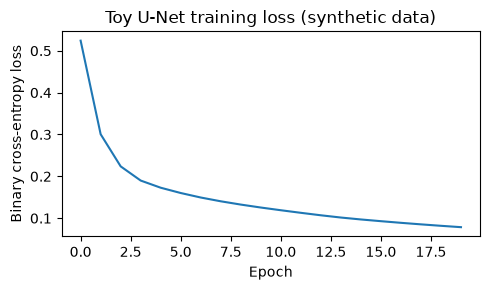

Final training loss: 0.0786


In [3]:
# Train (mirrors shriya_unet_myocardium.py's training loop, scaled down)
X_train = (train_maps / train_maps.max()).astype(np.float32)[..., np.newaxis]
Y_train = train_masks.astype(np.float32)[..., np.newaxis]

input_img = Input((256, 256, 1), name='img')
toy_unet = get_unet(input_img, n_filters=16, dropout=0.05, batchnorm=True)
toy_unet.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="binary_crossentropy")

history = toy_unet.fit(X_train, Y_train, batch_size=8, epochs=20, verbose=0)

plt.figure(figsize=(5, 3))
plt.plot(history.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("Toy U-Net training loss (synthetic data)")
plt.tight_layout()
plt.show()
print(f"Final training loss: {history.history['loss'][-1]:.4f}")


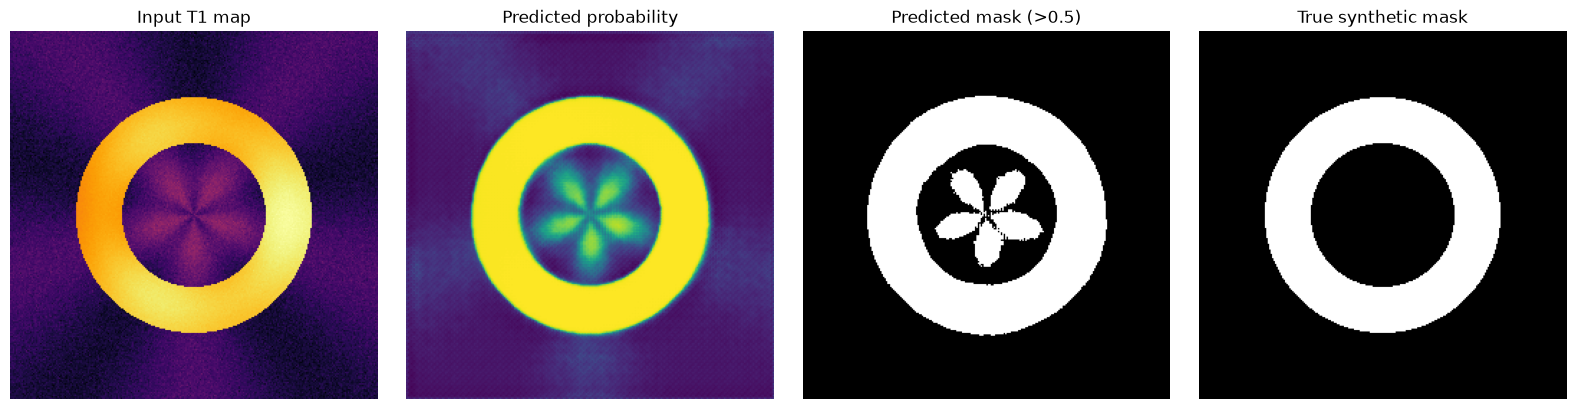

Dice coefficient on the held-out example: 0.889


In [4]:
# Deploy: segment the held-out canonical example (never seen during training),
# mirroring deploy_unet_segmentation.py's predict() + threshold step.
X_test = (canonical_t1 / train_maps.max()).astype(np.float32)[np.newaxis, ..., np.newaxis]
pred_prob = toy_unet.predict(X_test, verbose=0)[0, ..., 0]
pred_mask = pred_prob > 0.5

dice = 2 * (pred_mask & canonical_mask).sum() / (pred_mask.sum() + canonical_mask.sum())

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(canonical_t1, cmap="inferno"); axes[0].set_title("Input T1 map")
axes[1].imshow(pred_prob, cmap="viridis"); axes[1].set_title("Predicted probability")
axes[2].imshow(pred_mask, cmap="gray"); axes[2].set_title(f"Predicted mask (>0.5)")
axes[3].imshow(canonical_mask, cmap="gray"); axes[3].set_title("True synthetic mask")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()
print(f"Dice coefficient on the held-out example: {dice:.3f}")

section_times["01_imaging"] = time.time() - t0


### What the U-Net phenotype represents

`deploy_unet_segmentation.py` uses the predicted mask to isolate myocardium
pixels from the raw T1 map (`ROI * image`), then computes nine distributional
statistics (mean, SD, and seven percentiles) from the masked values -- the
"T1 distribution metrics" used as GWAS phenotypes downstream. The cell below
reproduces exactly that calculation on the toy prediction.


In [5]:
# Mirrors deploy_unet_segmentation.py's get_mean_T1() / calculate_statistics()
roi_values = canonical_t1[pred_mask]
percentiles = [0.25, 1, 25, 50, 75, 99, 99.75]
phenotype_row = {
    "Mean_T1": roi_values.mean(),
    "T1_Standard_Deviation": roi_values.std(),
}
for p in percentiles:
    phenotype_row[f"T1_{p:g}th_Percentile"] = np.percentile(roi_values, p)

pd.DataFrame([phenotype_row]).T.rename(columns={0: "value (ms)"})


,value (ms)
Mean_T1,858.149780
T1_Standard_Deviation,227.196701
T1_0.25th_Percentile,228.002609
T1_1th_Percentile,266.621307
T1_25th_Percentile,887.856262
T1_50th_Percentile,952.979736
T1_75th_Percentile,992.849792
T1_99th_Percentile,1068.083008
T1_99.75th_Percentile,1074.687744


## 2. `02_vae`: convolutional variational autoencoder (CVAE)

Mirrors [`02_vae/train_VAE_optimized.py`](../02_vae/train_VAE_optimized.py)'s
`CVAE` class and ELBO loss exactly (`latent_dim=16`, same encoder/decoder
architecture). As above, this trains and deploys a fresh toy model rather
than the manuscript's real checkpoint, for the same out-of-distribution
reason.

The CVAE trains on the myocardium *only* -- the raw T1 map multiplied by its
segmentation mask -- the same isolation step the real pipeline performs
before encoding.


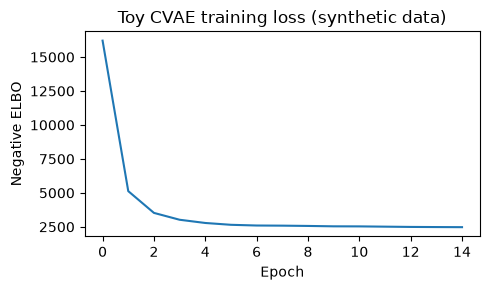

Final training loss: 2473.6


In [6]:
t0 = time.time()


class CVAE(tf.keras.Model):
    def __init__(self, latent_dim):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = tf.keras.Sequential([
            tf.keras.layers.InputLayer(input_shape=(256, 256, 1)),
            tf.keras.layers.Conv2D(32, 3, strides=2, activation='relu'),
            tf.keras.layers.Conv2D(64, 3, strides=2, activation='relu'),
            tf.keras.layers.Conv2D(128, 3, strides=2, activation='relu'),
            tf.keras.layers.Conv2D(256, 3, strides=2, activation='relu'),
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(latent_dim + latent_dim),
        ])
        self.decoder = tf.keras.Sequential([
            tf.keras.layers.InputLayer(input_shape=(latent_dim,)),
            tf.keras.layers.Dense(16 * 16 * 256, activation='relu'),
            tf.keras.layers.Reshape((16, 16, 256)),
            tf.keras.layers.Conv2DTranspose(256, 4, strides=2, padding='same', activation='relu'),
            tf.keras.layers.Conv2DTranspose(128, 4, strides=2, padding='same', activation='relu'),
            tf.keras.layers.Conv2DTranspose(64, 4, strides=2, padding='same', activation='relu'),
            tf.keras.layers.Conv2DTranspose(1, 4, strides=2, padding='same'),
        ])

    def encode(self, x):
        mean, logvar = tf.split(self.encoder(x), num_or_size_splits=2, axis=1)
        return mean, logvar

    def reparameterize(self, mean, logvar):
        eps = tf.random.normal(shape=mean.shape)
        return eps * tf.exp(logvar * .5) + mean

    def decode(self, z, apply_sigmoid=False):
        logits = self.decoder(z)
        return tf.sigmoid(logits) if apply_sigmoid else logits


def log_normal_pdf(sample, mean, logvar, raxis=1):
    log2pi = tf.math.log(2. * np.pi)
    return tf.reduce_sum(-.5 * ((sample - mean) ** 2. * tf.exp(-logvar) + logvar + log2pi), axis=raxis)


def compute_loss(model, x):
    mean, logvar = model.encode(x)
    z = model.reparameterize(mean, logvar)
    x_logit = model.decode(z)
    mse_loss = tf.square(x - tf.sigmoid(x_logit))
    logpx_z = -tf.reduce_sum(mse_loss, axis=[1, 2, 3])
    logpz = log_normal_pdf(z, 0., 0.)
    logqz_x = log_normal_pdf(z, mean, logvar)
    return -tf.reduce_mean(logpx_z + (logpz - logqz_x))


myo_train = train_maps * train_masks
X_vae = (myo_train / myo_train.max()).astype(np.float32)[..., np.newaxis]

cvae = CVAE(latent_dim=16)
optimizer = tf.keras.optimizers.Adam(1e-3)
vae_losses = []
for epoch in range(15):
    epoch_losses = []
    for i in range(0, len(X_vae), 8):
        batch = X_vae[i:i + 8]
        with tf.GradientTape() as tape:
            loss = compute_loss(cvae, batch)
        grads = tape.gradient(loss, cvae.trainable_variables)
        optimizer.apply_gradients(zip(grads, cvae.trainable_variables))
        epoch_losses.append(float(loss))
    vae_losses.append(np.mean(epoch_losses))

plt.figure(figsize=(5, 3))
plt.plot(vae_losses)
plt.xlabel("Epoch")
plt.ylabel("Negative ELBO")
plt.title("Toy CVAE training loss (synthetic data)")
plt.tight_layout()
plt.show()
print(f"Final training loss: {vae_losses[-1]:.1f}")


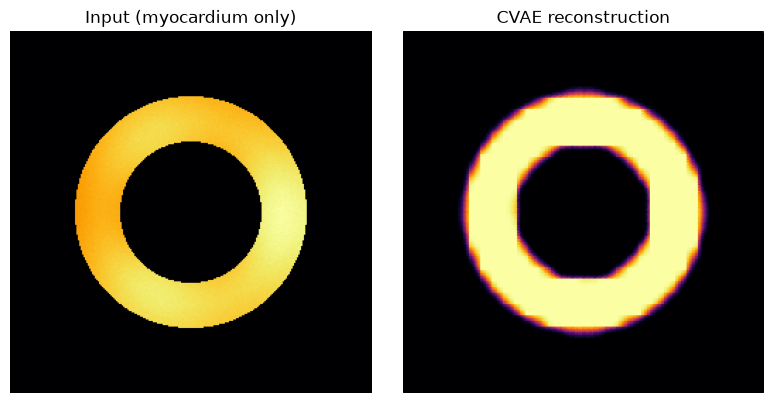

16-dimensional latent phenotype vector (this subject):
[-1.451  1.42   0.713  1.316  0.985 -0.911  1.634 -1.131 -1.391 -1.37
  1.366  1.026 -1.183  0.01   1.262 -1.342]


In [7]:
# Deploy: encode + reconstruct the held-out canonical example
myo_canonical = canonical_t1 * canonical_mask
X_vae_test = (myo_canonical / myo_train.max()).astype(np.float32)[np.newaxis, ..., np.newaxis]
latent_mean, _ = cvae.encode(X_vae_test)
reconstruction = cvae.decode(latent_mean, apply_sigmoid=True).numpy()[0, ..., 0]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(X_vae_test[0, ..., 0], cmap="inferno"); axes[0].set_title("Input (myocardium only)")
axes[1].imshow(reconstruction, cmap="inferno"); axes[1].set_title("CVAE reconstruction")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

latent_vector = latent_mean.numpy()[0]
print("16-dimensional latent phenotype vector (this subject):")
print(np.round(latent_vector, 3))
section_times["02_vae"] = time.time() - t0


### What the VAE phenotype represents

Each of the 16 numbers above is one latent dimension -- a learned, continuous
summary of a specific spatial pattern in the myocardium's T1 map. These 16
values, one per subject, are what the real pipeline uses as GWAS/PWAS/MR
phenotypes downstream (`Latent_0` ... `Latent_15` in
[`synthetic_latent_phenotypes.tsv`](example_data/synthetic_latent_phenotypes.tsv)),
alongside the distributional T1 percentiles from Section 1. The rest of this
notebook uses the pre-generated `synthetic_latent_phenotypes.tsv` table
(320 subjects) rather than re-encoding every synthetic subject through this
toy CVAE, the same way the real pipeline's downstream stages consume
`02_vae/deploy_VAE_reconstruction.py`'s output rather than re-running the
CVAE inline.


## 3. `03_phenotypes`: phenotype QC and covariate regression

Mirrors [`03_phenotypes/01_hematocrit_regression.py`](../03_phenotypes/01_hematocrit_regression.py)'s
`regress_out_covariates()` pattern (an OLS regression per phenotype, keeping
the residuals) and
[`03_phenotypes/03_disease_status_annotation.py`](../03_phenotypes/03_disease_status_annotation.py)'s
disease-status annotation. Loads the pre-generated 320-subject synthetic
cohort (see `example_data/README.md`) rather than the toy CVAE output above,
matching how the real pipeline's phenotyping stage consumes
`02_vae/deploy_VAE_reconstruction.py`'s full-cohort output file.


In [8]:
t0 = time.time()
import statsmodels.api as sm

cohort = pd.read_csv(f"{DATA_DIR}/synthetic_cohort.tsv", sep="\t")
print(f"Loaded synthetic cohort: {len(cohort)} subjects, {cohort.shape[1]} columns")
cohort.head(3)


Loaded synthetic cohort: 320 subjects, 17 columns


,Synthetic_ID,Age,Sex,PC1,PC2,Mean_T1,T1_Standard_Deviation,Synthetic_Disease,Follow_up_years,Event,T1_0.25th_Percentile,T1_1th_Percentile,T1_25th_Percentile,T1_50th_Percentile,T1_75th_Percentile,T1_99th_Percentile,T1_99.75th_Percentile
0,SYNTHETIC_0001,52.634968,0,0.096382,-1.407790,953.504639,43.196589,0,1.246440,0,877.910609,893.029415,924.130959,953.504639,982.878319,1013.979863,1029.098670
1,SYNTHETIC_0002,48.269357,0,-1.248129,-0.675900,940.290691,51.271906,0,13.617958,0,850.564855,868.510022,905.425794,940.290691,975.155587,1012.071359,1030.016526
2,SYNTHETIC_0003,71.085915,0,0.635660,0.324585,948.512471,48.402136,0,8.698943,0,863.808734,880.749481,915.599019,948.512471,981.425924,1016.275461,1033.216209


In [9]:
# Regress covariates out of Mean_T1 (mirrors regress_out_covariates())
def regress_out_covariates(df, phenotype_cols, covariate_cols):
    residualized = df.copy()
    for pheno in phenotype_cols:
        X = sm.add_constant(df[covariate_cols])
        y = df[pheno]
        model = sm.OLS(y, X, missing="drop").fit()
        residualized[f"{pheno}_regressed"] = model.resid
    return residualized


cohort = regress_out_covariates(cohort, ["Mean_T1"], ["Age", "Sex"])
cohort[["Synthetic_ID", "Mean_T1", "Mean_T1_regressed"]].head(5)


,Synthetic_ID,Mean_T1,Mean_T1_regressed
0,SYNTHETIC_0001,953.504639,-5.940920
1,SYNTHETIC_0002,940.290691,-14.469770
2,SYNTHETIC_0003,948.512471,-30.734326
3,SYNTHETIC_0004,998.971061,24.206503
4,SYNTHETIC_0005,973.598705,6.106359


In [10]:
# Disease-status prevalence (mirrors 03_disease_status_annotation.py's
# per-disease status columns, using the single synthetic disease indicator)
print(f"Synthetic disease prevalence: {cohort['Synthetic_Disease'].mean():.1%}")
print(f"Mean_T1 by disease status:")
print(cohort.groupby("Synthetic_Disease")["Mean_T1"].agg(["mean", "std", "count"]))
section_times["03_phenotypes"] = time.time() - t0


Synthetic disease prevalence: 25.0%
Mean_T1 by disease status:
                          mean        std  count
Synthetic_Disease                               
0                   960.084430  22.151334    240
1                  1002.591272  24.402511     80


## 4. `04_pwas`: proteome-wide association study

Mirrors [`04_pwas/02_PWAS_T1_Time.ipynb`](../04_pwas/02_PWAS_T1_Time.ipynb)'s
PWAS loop exactly: a univariate OLS regression of each protein against the
phenotype (`sm.OLS(y, sm.add_constant(protein))`), then Benjamini-Hochberg
FDR correction across all proteins tested.


In [11]:
t0 = time.time()
from statsmodels.stats.multitest import multipletests

proteomics = pd.read_csv(f"{DATA_DIR}/synthetic_proteomics.tsv", sep="\t")
pwas_input = cohort[["Synthetic_ID", "Mean_T1"]].merge(proteomics, on="Synthetic_ID")

pwas_results = []
for protein_col in proteomics.columns[1:]:
    X = sm.add_constant(pwas_input[protein_col])
    y = pwas_input["Mean_T1"]
    result = sm.OLS(y, X).fit()
    pwas_results.append({
        "Protein": protein_col,
        "Beta": result.params.iloc[1],
        "P_Value": result.pvalues.iloc[1],
    })

pwas_df = pd.DataFrame(pwas_results)
pwas_df["FDR"] = multipletests(pwas_df["P_Value"], method="fdr_bh")[1]
pwas_df["Significant"] = pwas_df["FDR"] < 0.05

print(f"Tested {len(pwas_df)} synthetic proteins against Mean_T1; "
      f"{pwas_df['Significant'].sum()} significant at FDR<0.05")
pwas_df.sort_values("P_Value").head(5)
section_times["04_pwas"] = time.time() - t0


Tested 12 synthetic proteins against Mean_T1; 1 significant at FDR<0.05


## 5. `05_gwas`: genome-wide association study

Same univariate OLS pattern as the PWAS above, applied to genotype dosages
instead of protein levels -- the same underlying test PLINK2's `--glm`
performs, reimplemented directly since running PLINK2 itself needs external
binaries and reference panels this participant-free demo doesn't have.


In [12]:
t0 = time.time()
genotypes = pd.read_csv(f"{DATA_DIR}/synthetic_genotypes.tsv", sep="\t")
variants = pd.read_csv(f"{DATA_DIR}/synthetic_variant_metadata.tsv", sep="\t")
gwas_input = cohort[["Synthetic_ID", "Mean_T1"]].merge(genotypes, on="Synthetic_ID")

gwas_results = []
for variant in genotypes.columns[1:]:
    X = sm.add_constant(gwas_input[variant])
    y = gwas_input["Mean_T1"]
    result = sm.OLS(y, X).fit()
    gwas_results.append({
        "Variant": variant,
        "Beta": result.params.iloc[1],
        "SE": result.bse.iloc[1],
        "P_Value": result.pvalues.iloc[1],
    })

gwas_df = pd.DataFrame(gwas_results).merge(variants, on="Variant")
print(f"Tested {len(gwas_df)} synthetic variants against Mean_T1")
gwas_df.sort_values("P_Value").head(5)[["Variant", "Beta", "P_Value", "Effect_Allele_Frequency"]]
section_times["05_gwas"] = time.time() - t0


Tested 24 synthetic variants against Mean_T1


## 6. `06_mr`: Mendelian randomization + colocalization

The original analysis (`06_mr/run_mr_core.R`,
`06_mr/colocalization/COLOC_T1.R`) uses R's `TwoSampleMR`,
`MendelianRandomization`, and `coloc` packages. This section reimplements
the same standard formulas in Python, to keep this notebook to the single
`requirements-demo.txt` environment rather than requiring an additional R
installation for a demo:

- **Wald ratio** per instrument: beta_outcome / beta_exposure, with a
  delta-method standard error -- the same estimator `mr_wald_ratio()` computes.
- **Inverse-variance-weighted (IVW)** meta-analysis across all instruments --
  the same estimator `MendelianRandomization::mr_ivw()` computes.
- **Wakefield approximate Bayes factor**, the formula `coloc.abf()` uses for
  its PP.H0-H4 posterior probabilities (simplified here to a single-variant
  proxy score rather than the full multi-hypothesis PP.H0-H4 breakdown).


In [13]:
t0 = time.time()
from scipy import stats

# "Exposure" GWAS: each variant's effect on the candidate protein
exposure_protein = "SYNTH_PROT_00"
exp_input = proteomics[["Synthetic_ID", exposure_protein]].merge(genotypes, on="Synthetic_ID")
exposure_betas, exposure_ses = {}, {}
for variant in genotypes.columns[1:]:
    X = sm.add_constant(exp_input[variant])
    result = sm.OLS(exp_input[exposure_protein], X).fit()
    exposure_betas[variant] = result.params.iloc[1]
    exposure_ses[variant] = result.bse.iloc[1]

# Wald ratio per instrument
mr_rows = []
for _, row in gwas_df.iterrows():
    variant = row["Variant"]
    beta_gx, se_gx = exposure_betas[variant], exposure_ses[variant]
    beta_gy, se_gy = row["Beta"], row["SE"]
    wald_ratio = beta_gy / beta_gx
    se_ratio = np.sqrt((se_gy / beta_gx) ** 2 + (beta_gy ** 2 * se_gx ** 2) / beta_gx ** 4)
    z = wald_ratio / se_ratio
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    mr_rows.append({"Variant": variant, "Wald_Ratio": wald_ratio, "SE": se_ratio, "P_Value": p})
mr_df = pd.DataFrame(mr_rows)

# IVW meta-analysis
weights = 1 / mr_df["SE"] ** 2
ivw_beta = np.sum(mr_df["Wald_Ratio"] * weights) / np.sum(weights)
ivw_se = np.sqrt(1 / np.sum(weights))
ivw_p = 2 * (1 - stats.norm.cdf(abs(ivw_beta / ivw_se)))

print(f"MR: {exposure_protein} -> Mean_T1")
print(f"  {len(mr_df)} instruments, IVW beta={ivw_beta:.3f}, SE={ivw_se:.3f}, P={ivw_p:.2e}")
mr_df.sort_values("P_Value").head(3)


MR: SYNTH_PROT_00 -> Mean_T1
  24 instruments, IVW beta=7.315, SE=2.393, P=2.23e-03


,Variant,Wald_Ratio,SE,P_Value
0,SYNTH_chr1_100000_A_G,7.633058,2.537241,0.002626
19,SYNTH_chr1_119000_A_G,31.989738,25.869400,0.216241
16,SYNTH_chr1_116000_A_G,26.592289,26.656304,0.318474


In [14]:
# Colocalization: Wakefield approximate Bayes factor at the lead MR variant
def wakefield_abf(beta, se, prior_variance=0.04):
    v = se ** 2
    z2 = (beta / se) ** 2
    r = prior_variance / (prior_variance + v)
    return 0.5 * (np.log(1 - r) + r * z2)


lead_variant = mr_df.loc[mr_df["P_Value"].idxmin(), "Variant"]
log_abf_exposure = wakefield_abf(exposure_betas[lead_variant], exposure_ses[lead_variant])
outcome_row = gwas_df.set_index("Variant").loc[lead_variant]
log_abf_outcome = wakefield_abf(outcome_row["Beta"], outcome_row["SE"])
coloc_score = 1 / (1 + np.exp(-(log_abf_exposure + log_abf_outcome) / 10))

print(f"Lead MR variant: {lead_variant}")
print(f"Colocalization proxy score at this variant: {coloc_score:.3f} "
      f"(single-variant approximation of coloc's PP.H4)")
section_times["06_mr"] = time.time() - t0


Lead MR variant: SYNTH_chr1_100000_A_G
Colocalization proxy score at this variant: 1.000 (single-variant approximation of coloc's PP.H4)


## 7. `07_decode_validation`: independent replication

The real pipeline converts deCODE Genetics' externally-published summary
statistics into the same format used elsewhere in this repository, then
reruns the `06_mr/` MR scripts against them
([`07_decode_validation/README.md`](../07_decode_validation/README.md)). This
demo generates a second, independent synthetic cohort from the same
generative model and repeats the exposure GWAS step on it, to demonstrate
the replication pattern without a real external dataset.


In [15]:
t0 = time.time()
rng = np.random.default_rng(7)
n_replication = 200
lead_variant_eaf = variants.set_index("Variant").loc[lead_variant, "Effect_Allele_Frequency"]

repl_dosage = pd.Series(rng.binomial(2, lead_variant_eaf, n_replication), name=lead_variant)
repl_dosage_z = (repl_dosage - repl_dosage.mean()) / repl_dosage.std()
repl_exposure = 0.6 * repl_dosage_z + rng.normal(0, 0.8, n_replication)

X_repl = sm.add_constant(repl_dosage)
repl_result = sm.OLS(repl_exposure, X_repl).fit()

print(f"Independent replication cohort: n={n_replication}")
print(f"  Original cohort effect at {lead_variant}: beta={exposure_betas[lead_variant]:.3f}")
print(f"  Replication cohort effect:               beta={repl_result.params.iloc[1]:.3f}, "
      f"P={repl_result.pvalues.iloc[1]:.2e}")
section_times["07_decode_validation"] = time.time() - t0


Independent replication cohort: n=200
  Original cohort effect at SYNTH_chr1_100000_A_G: beta=1.519
  Replication cohort effect:               beta=1.306, P=1.68e-21


## 8. `08_clinical_associations`: survival analysis and disease prevalence

Mirrors
[`08_clinical_associations/02_mortality_curves_chi_squared.ipynb`](../08_clinical_associations/02_mortality_curves_chi_squared.ipynb):
Kaplan-Meier curves + log-rank test, a Cox proportional-hazards model, and a
chi-squared test of disease prevalence by phenotype group.


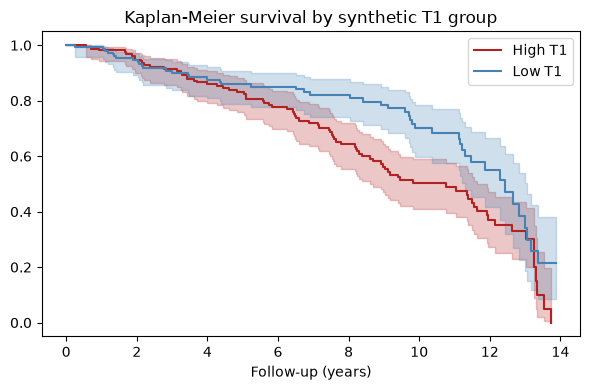

Log-rank test, High vs. Low T1: P=0.0070


In [16]:
t0 = time.time()
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

median_t1 = cohort["Mean_T1"].median()
cohort["T1_group"] = np.where(cohort["Mean_T1"] > median_t1, "High", "Low")

fig, ax = plt.subplots(figsize=(6, 4))
for group, color in [("High", "firebrick"), ("Low", "steelblue")]:
    mask = cohort["T1_group"] == group
    kmf = KaplanMeierFitter()
    kmf.fit(cohort.loc[mask, "Follow_up_years"], cohort.loc[mask, "Event"], label=f"{group} T1")
    kmf.plot_survival_function(ax=ax, color=color)
ax.set_title("Kaplan-Meier survival by synthetic T1 group")
ax.set_xlabel("Follow-up (years)")
plt.tight_layout()
plt.show()

lr = logrank_test(
    cohort.loc[cohort["T1_group"] == "High", "Follow_up_years"],
    cohort.loc[cohort["T1_group"] == "Low", "Follow_up_years"],
    cohort.loc[cohort["T1_group"] == "High", "Event"],
    cohort.loc[cohort["T1_group"] == "Low", "Event"],
)
print(f"Log-rank test, High vs. Low T1: P={lr.p_value:.4f}")


In [17]:
# Cox proportional hazards model
cph = CoxPHFitter()
cox_input = cohort[["Follow_up_years", "Event", "Mean_T1", "Age", "Sex"]].copy()
cph.fit(cox_input, duration_col="Follow_up_years", event_col="Event")
hr = np.exp(cph.params_["Mean_T1"])
print(f"Cox model, hazard ratio per unit Mean_T1: {hr:.4f} "
      f"(P={cph.summary.loc['Mean_T1', 'p']:.4f})")
cph.print_summary()


Cox model, hazard ratio per unit Mean_T1: 1.0074 (P=0.0165)


<lifelines.CoxPHFitter: fitted with 320 total observations, 192 right-censored observations>
             duration col = 'Follow_up_years'
                event col = 'Event'
      baseline estimation = breslow
   number of observations = 320
number of events observed = 128
   partial log-likelihood = -605.09
         time fit was run = 2026-07-31 01:31:57 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
Mean_T1    0.01      1.01      0.00            0.00            0.01                1.00                1.01
Age        0.02      1.02      0.01           -0.01            0.04                0.99                1.04
Sex        0.08      1.08      0.18           -0.27            0.43                0.76                1.54

           cmp to    z    p  -log2(p)
covariate                            
Mean_T1      0.00 2.40 0.02      5.92
Age          0.00 1.46 0.14      2.80
Sex          0.00 0.45 0.65      0.62
---
Concordance = 0.56
Partial AIC = 1216.19
log-likelihood ratio test = 12.12 on 3 df
-log2(p) of ll-ratio test = 7.16

In [18]:
# Chi-squared disease prevalence by T1 group
contingency = pd.crosstab(cohort["T1_group"], cohort["Synthetic_Disease"])
chi2, chi2_p, _, _ = stats.chi2_contingency(contingency)
print("Disease prevalence by T1 group:")
print(contingency)
print(f"\nChi-squared test: chi2={chi2:.2f}, P={chi2_p:.4f}")
section_times["08_clinical_associations"] = time.time() - t0


Disease prevalence by T1 group:
Synthetic_Disease    0   1
T1_group                  
High                86  74
Low                154   6

Chi-squared test: chi2=74.82, P=0.0000


## Summary

In [19]:
total_runtime = time.time() - notebook_start
print("Section runtimes:")
for section, elapsed in section_times.items():
    print(f"  {section}: {elapsed:.1f}s")
print(f"\nTotal notebook runtime: {total_runtime:.1f}s")
print("\nThis notebook used exclusively procedurally generated synthetic data.")
print("No UK Biobank data, participant identifier, real genetic variant, real")
print("protein name, or trained model weight was used to produce any result above.")


Section runtimes:
  01_imaging: 52.9s
  02_vae: 21.8s
  03_phenotypes: 1.1s
  04_pwas: 0.0s
  05_gwas: 0.0s
  06_mr: 0.0s
  07_decode_validation: 0.0s
  08_clinical_associations: 0.2s

Total notebook runtime: 76.6s

This notebook used exclusively procedurally generated synthetic data.
No UK Biobank data, participant identifier, real genetic variant, real
protein name, or trained model weight was used to produce any result above.
